In [19]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian


In [ ]:
width = 40
X, Y = width, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.001, -0.001, 0.001j, -0.001j])


In [21]:
bdg_sc(H, atol=1e-3, rtol=1e-1, maxiter=200, temperature=T,verbose=True, mixing=0.75)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.7620132441523002e-16
Relative error: 0.00017620132441523005
Average old: 0j
Average: (-4.854731260759039e-18+0j)
F_xplus:
Absolute error: 0.0007667835888494104
Relative error: 0.7667835880826267
Average old: (0.0010000000000000002+0j)
Average: (0.001029634374430641+0j)
F_xmin:
Absolute error: 0.0007667835888493411
Relative error: 0.7667835896161246
Average old: (-0.0010000000000000002+0j)
Average: (-0.0010296343744306239+0j)
F_yplus:
Absolute error: 0.005240051621739897
Relative error: 5.240051621739897
Average old: 0.0010000000000000002j
Average: (-3.611582454327025e-18+0.0018281428135574426j)
F_ymin:
Absolute error: 0.005240051621739897
Relative error: 5.240051621739897
Average old: -0.0010000000000000002j
Average: (-3.611582454327025e-18-0.0018281428135574426j)
Fuu_xplus:
Absolute error: 9.657717949179056e-18
Relative error: 9.657717949179056e-06
Average old: 0j
Average: (-4.052178893482956e-19+0j)
Fuu_xmin:
Absolute error: 8.343489065936431e-18
Relative error:

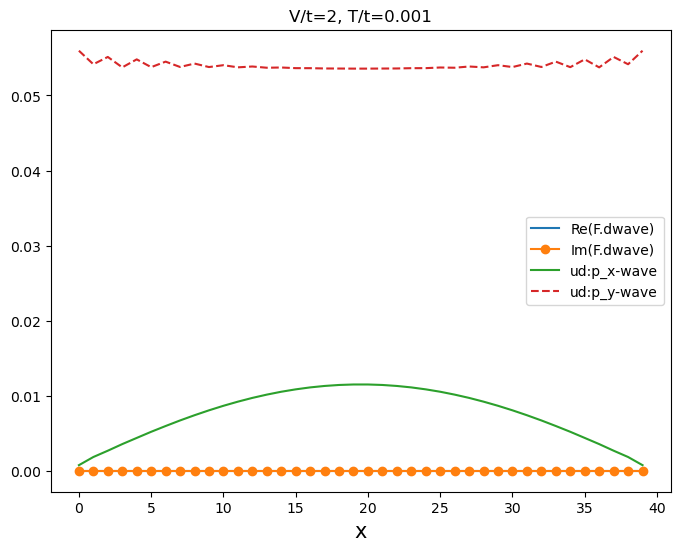

In [25]:
x = np.arange(0, width)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [23]:
print(F.px[X//2])
print(F.py[X//2])


(0.01148956964862437+0j)
0.053574146413545395j


In [24]:
temps = np.concatenate([
    np.arange(0.001, 0.100 + 1e-12, 0.005),
    np.arange(0.102, 0.120+1e-12, 0.0001),
    np.arange(0.125, 0.150 + 1e-12, 0.005),
])  # 207 temps total
print(len(temps))
print(temps)

207
[0.001  0.006  0.011  0.016  0.021  0.026  0.031  0.036  0.041  0.046
 0.051  0.056  0.061  0.066  0.071  0.076  0.081  0.086  0.091  0.096
 0.102  0.1021 0.1022 0.1023 0.1024 0.1025 0.1026 0.1027 0.1028 0.1029
 0.103  0.1031 0.1032 0.1033 0.1034 0.1035 0.1036 0.1037 0.1038 0.1039
 0.104  0.1041 0.1042 0.1043 0.1044 0.1045 0.1046 0.1047 0.1048 0.1049
 0.105  0.1051 0.1052 0.1053 0.1054 0.1055 0.1056 0.1057 0.1058 0.1059
 0.106  0.1061 0.1062 0.1063 0.1064 0.1065 0.1066 0.1067 0.1068 0.1069
 0.107  0.1071 0.1072 0.1073 0.1074 0.1075 0.1076 0.1077 0.1078 0.1079
 0.108  0.1081 0.1082 0.1083 0.1084 0.1085 0.1086 0.1087 0.1088 0.1089
 0.109  0.1091 0.1092 0.1093 0.1094 0.1095 0.1096 0.1097 0.1098 0.1099
 0.11   0.1101 0.1102 0.1103 0.1104 0.1105 0.1106 0.1107 0.1108 0.1109
 0.111  0.1111 0.1112 0.1113 0.1114 0.1115 0.1116 0.1117 0.1118 0.1119
 0.112  0.1121 0.1122 0.1123 0.1124 0.1125 0.1126 0.1127 0.1128 0.1129
 0.113  0.1131 0.1132 0.1133 0.1134 0.1135 0.1136 0.1137 0.1138 0.1139
 0.1